# Airbnb Guest Review Sentiment Analysis

# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from collections import Counter
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords
from langdetect import detect, LangDetectException
from wordcloud import STOPWORDS

# 2. Dataset Overview

In [ ]:
df = pd.read_csv("NYC_2021_airbnb_reviews_data1.csv")

df.shape

df.info()

df.isnull().sum()

# 3. Data Cleaning and Preprocessing

Remove duplicate reviews

In [4]:
df = df.drop_duplicates(subset=["review"])
df.shape

(17218, 4)

Strip extra space

In [5]:
df["review"] = df["review"].str.strip()

Remove empty reviews

In [6]:
df = df[df["review"] != ""]
print("Rows:", len(df))

Rows: 17218


In [7]:
df.columns
print(df["listing_id"].nunique())
print(df.shape)

219
(17218, 4)


In [8]:
df["review"].str.len().describe()
df["review"].isnull().sum()

np.int64(0)

### Creating "review_length" feature

In [9]:
df["review_length"] = df["review"].str.len()

df["review_length"].describe()

count    17218.000000
mean       341.678186
std        317.392897
min          1.000000
25%        132.000000
50%        259.000000
75%        448.000000
max       5452.000000
Name: review_length, dtype: float64

Visualizing review length

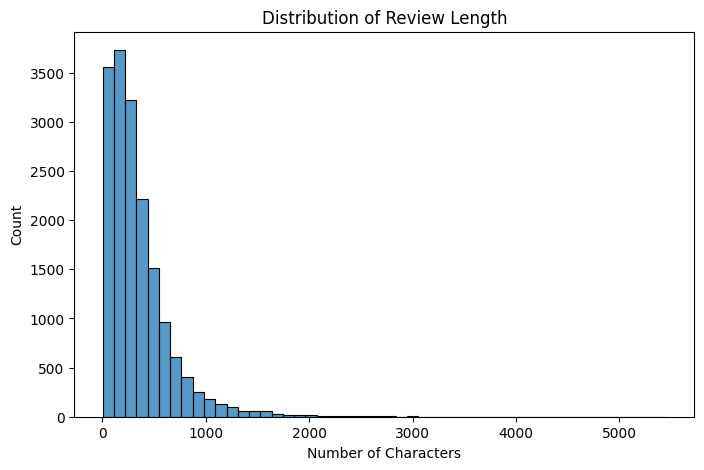

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["review_length"],
    bins=50
)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Characters")

plt.show()

### Observation

The distribution of "review_length" exhibited a positively skewed pattern, with the majority of reviews being short to medium length and a small number of very long reviews. 

Language Detection

In [11]:
def detect_lang(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return "unknown"

df["language"] = df["review"].apply(detect_lang)

print(df["language"].value_counts().head(20))

language
en         15974
fr           477
es           221
de           180
it            60
nl            42
pt            38
ko            23
ja            20
zh-cn         18
ro            17
af            16
so            14
ca            12
ru            12
unknown       10
no             9
id             8
sv             8
da             8
Name: count, dtype: int64


In [12]:
df = df[df["language"] == "en"]

### Observation
Language detection was performed using the langdetect library. Since VADER is designed for English text, only reviews identified as English were retained for sentiment analysis. Approximately 92.8% of reviews were in English, ensuring minimal information loss while improving sentiment analysis reliability.

# 4. Sentiment Analysis using VADER

In [13]:
analyzer = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["review"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

Create sentiment labels

In [14]:
def get_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["sentiment_score"].apply(
    get_sentiment
)

df["sentiment"].value_counts()

sentiment
Positive    15564
Neutral       218
Negative      192
Name: count, dtype: int64

# 5. Sentiment Distribution Analysis

Plot sentiments

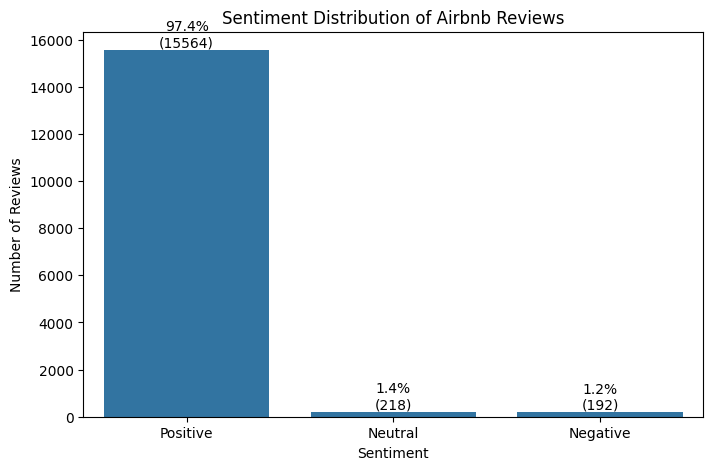

In [15]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="sentiment",
    data=df,
    order=["Positive", "Neutral", "Negative"]
)

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(
        f"{percentage:.1f}%\n({count})",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Sentiment Distribution of Airbnb Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

### Observation

The sentiment analysis showed that most Airbnb reviews were positive (92.97%), indicating high overall guest satisfaction, while only a small proportion of reviews were neutral (4.08%) or negative (2.95%).

Create a separate cleaned text column

In [16]:
df["clean_review"] = df["review"].str.lower()

df["clean_review"] = df["clean_review"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x)
)

In [17]:
df["clean_review"].head()

0    great location convenient to everything very c...
1    place was so cute and comfy host was great and...
2                                     would stay again
3    the apartment met expectations to how it was i...
4    great space in a fun old building in nyc loved...
Name: clean_review, dtype: object

Word Cloud / Frequent words

In [18]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

df["clean_review"] = df["clean_review"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Stopping words(for,an,in,the,many,more,it,to,is, etc) removed, also removed some custom words that were common in positive reviewss( apartments,nyc,rooms,host, etc)

# 6. Word Cloud Analysis

### Word cloud for positive reviews

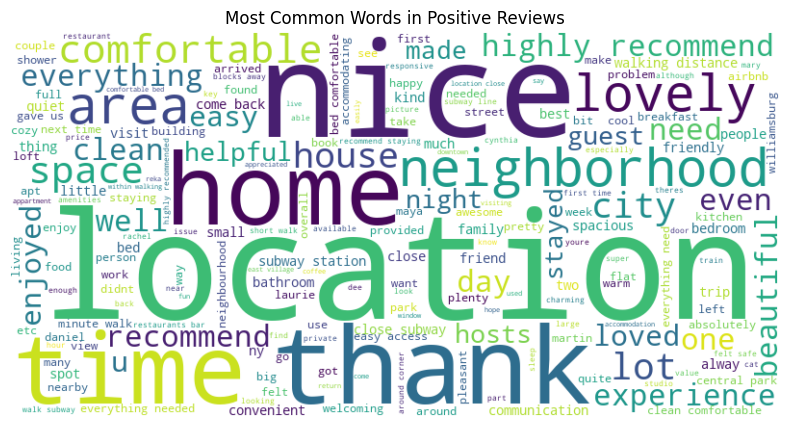

In [19]:
positive_text = " ".join(
    df[df["sentiment"] == "Positive"]["clean_review"]
)

custom_stopwords = STOPWORDS.union({"apartment","room","host","place","stay","new","york","nyc",
                                    "brooklyn","manhattan","great","good","love","really","definitely",
                                    "amazing","wonderful","perfect","excellent","fantastic"})

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=custom_stopwords
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Positive Reviews")
plt.show()

### Observation
The positive review word cloud highlights that guests most frequently appreciated location, comfort, cleanliness, neighbourhood quality, and overall convenience during their Airbnb stays.

### Word cloud for Negative reviews

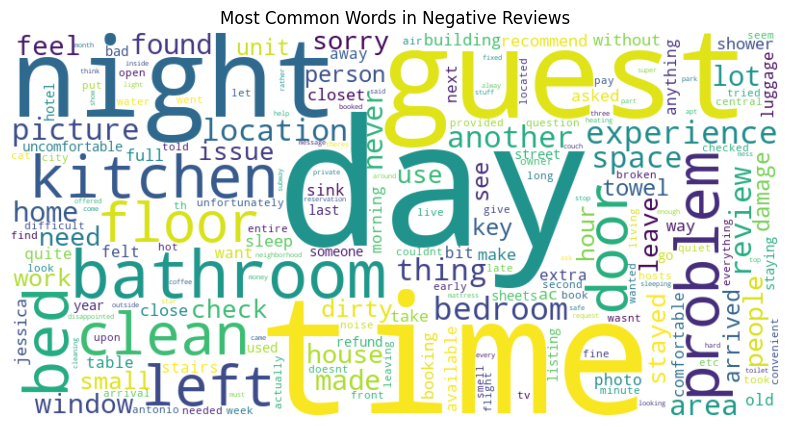

In [20]:
negative_text = " ".join(
    df[df["sentiment"] == "Negative"]["clean_review"]
)

# custom_stopwords = custom_stopwords.union({
#     "guest", "guests", "day", "days","apartment", "room"
# })
custom_stopwords = custom_stopwords.union({
    "first","one","two","us","even","nice",
    "didnt","dont","im","ive","got","say",
    "really","much","many","well","airbnb"
})

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=custom_stopwords
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.show()

# Observation

After removing generic Airbnb-related terms, the most common negative words were associated with cleanliness, bathroom and kitchen conditions, room quality, and service-related aspects frequently mentioned in negative reviews.

### Sentiment Statistics Table

In [21]:
sent_stats = (
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Percentage")
)

sent_stats

,Percentage
sentiment,
Positive,97.43
Neutral,1.36
Negative,1.20


# 7. Most Frequent Words Analysis

### Top 20 Positive Words

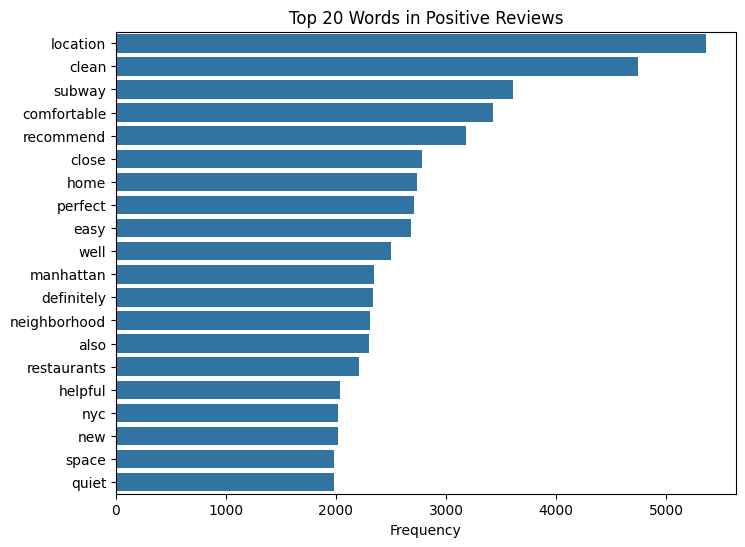

In [22]:
positive_words = " ".join(
    df[df["sentiment"]=="Positive"]["clean_review"]
).split()

positive_words = [
    w for w in positive_words
    if w not in {
        "great","place","stay","apartment","host",
        "room","nice","would","us","really",
        "good","everything","time"
    }
]

positive_df = pd.DataFrame(
    Counter(positive_words).most_common(20),
    columns=["word", "count"]
)

plt.figure(figsize=(8,6))
sns.barplot(data=positive_df, x="count", y="word")
plt.title("Top 20 Words in Positive Reviews")
plt.xlabel("Frequency")
plt.ylabel("")
plt.show()

### Observation

Positive reviews most frequently mentioned location, cleanliness, comfort, accessibility to public transportation, and neighbourhood quality.

### Top 20 negative words

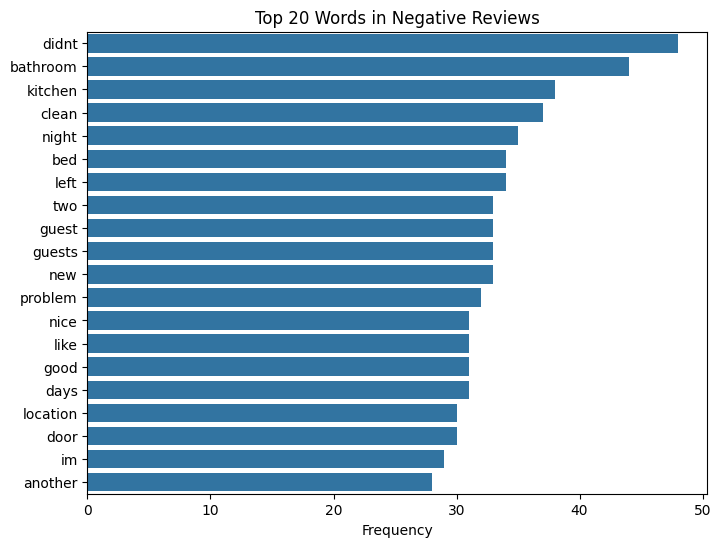

In [23]:
negative_words = " ".join(
    df[df["sentiment"]=="Negative"]["clean_review"]
).split()

negative_words = [
    w for w in negative_words
    if w not in {
        "apartment","place","stay","room","airbnb","host",
        "one","us","also","time","day","would","could",
        "first","really","get","got","back","still",
        "even","well","made","never"
    }
]

negative_df = pd.DataFrame(
    Counter(negative_words).most_common(20),
    columns=["word", "count"]
)

plt.figure(figsize=(8,6))
sns.barplot(data=negative_df, x="count", y="word")
plt.title("Top 20 Words in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("")
plt.show()

# Observation

After removing generic Airbnb-related terms, the most common negative words were associated with cleanliness, bathroom and kitchen conditions, room quality, and service-related issues, indicating the primary sources of guest dissatisfaction.

### Review Sentiment by length

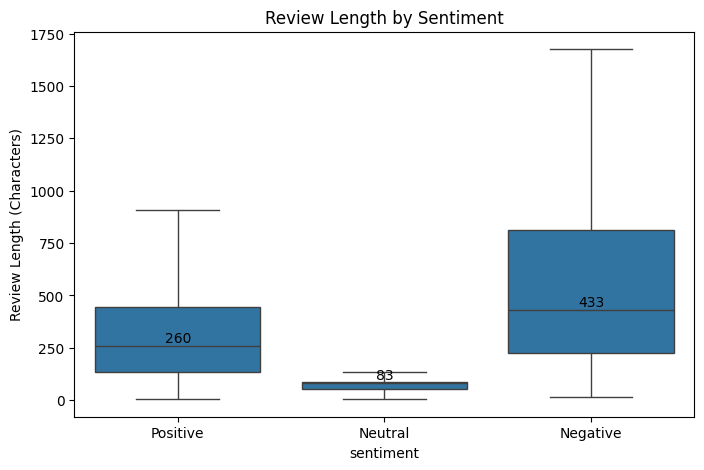

In [24]:

plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x="sentiment",
    y="review_length",
    data=df,
    showfliers=False
)

medians = df.groupby("sentiment")["review_length"].median()

for i, sentiment in enumerate(ax.get_xticklabels()):
    label = sentiment.get_text()
    ax.text(
        i,
        medians[label],
        f"{medians[label]:.0f}",
        ha="center",
        va="bottom"
    )

plt.title("Review Length by Sentiment")
plt.ylabel("Review Length (Characters)")

plt.show()

### Observation

Negative reviews were considerably longer (median = 434 characters) than positive reviews (median = 260 characters), indicating that dissatisfied guests tend to provide more detailed feedback regarding their experiences. Neutral reviews were the shortest (median = 83 characters), suggesting a more concise and factual writing style.

# 8. Key Insights



- Approximately 93% of Airbnb reviews were classified as positive, indicating high overall guest satisfaction.
- Guests frequently praised location, cleanliness, comfort, and host hospitality.
- Negative reviews were relatively rare and frequently mentioned aspects of the property such as bathrooms, kitchens, beds, and other accommodation-related features.
- Negative reviews tended to be longer than positive reviews, suggesting that dissatisfied guests often provide more detailed feedback.

# 9. Conclusion

The sentiment analysis of Airbnb guest reviews revealed overwhelmingly positive customer experiences. Using VADER sentiment analysis, most reviews were classified as positive, highlighting high levels of guest satisfaction. Common positive themes included location, cleanliness, and host responsiveness, while negative feedback was mainly associated with maintenance and communication concerns. Overall, most Airbnb guests reported positive experiences.